<a href="https://colab.research.google.com/github/Taniice/Analisis-Visitantes-a-Sitios-Arqueologicos/blob/main/Analisis_Visitas_a_Sitios_Arqueologicos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Analisis Visitantes a sitios arqueologicos
#INTEGRANTES
# Tania Pamela Apaza Vilca
#Jose Jhonatan Quispe Cartagena

In [2]:
# 1. IMPORTAR LIBRERÍAS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# 2. CONECTAR GOOGLE DRIVE
from google.colab import drive
drive.mount('/content/drive')

# 3. CARGAR BASE DE DATOS
ruta = "/content/drive/MyDrive/base de datos sitios_1.csv"

Mounted at /content/drive


In [4]:
#Obtener el dataframe
df = pd.read_csv(ruta, encoding='latin1', sep=';')

In [5]:
#Consultar las filas
print("Primeras filas:")
print(df.head())

#Consultar la información del dataframe
print("\nInformación:")
print(df.info())

# Mostrar resumen estadístico del DataFrame (media, mínimo, máximo, etc.)
print("\nDescripción estadística:")
print(df.describe())

Primeras filas:
   FECHA_CORTE  ANIO  COD_DPTO  NOM_DPTO                            NOM_MUSEO  \
0     20260505  2007         1  Amazonas  Zona Arqueológica Monumental Kuélap   
1     20260505  2007         1  Amazonas  Zona Arqueológica Monumental Kuélap   
2     20260505  2007         1  Amazonas  Zona Arqueológica Monumental Kuélap   
3     20260505  2007         1  Amazonas  Zona Arqueológica Monumental Kuélap   
4     20260505  2007         1  Amazonas  Zona Arqueológica Monumental Kuélap   

   COD_MES  NOM_MES  COD_TIPO     NOM_TIPO  ADU_BOLESPPAGANTES  ...  \
0        1    Enero         0   Nacionales                   0  ...   
1        1    Enero         1  Extranjeros                   0  ...   
2        2  Febrero         0   Nacionales                   0  ...   
3        2  Febrero         1  Extranjeros                   0  ...   
4        3    Marzo         0   Nacionales                   0  ...   

   EST_BOLESPNOPAGANTES  NIN_BOLESPNOPAGANTES  MIL_BOLESPNOPAGANTES  \

In [6]:
# 5. LIMPIEZA DE DATOS
# Convertir la columna TOTAL a numérico
df['TOTAL'] = pd.to_numeric(df['TOTAL'], errors='coerce')

# Eliminar valores nulos en TOTAL
df = df.dropna(subset=['TOTAL'])

In [13]:
#cambiamos nombres técnicos a nombres claros y entendibles
#Cambio de JOSE
df = df.rename(columns={
    'FECHA_CORTE': 'fecha',
    'ANIO': 'anio',
    'COD_DPTO': 'cod_departamento',
    'NOM_DPTO': 'departamento',
    'NOM_MUSEO': 'sitio',
    'COD_MES': 'cod_mes',
    'NOM_MES': 'mes',
    'COD_TIPO': 'cod_tipo_visitante',
    'NOM_TIPO': 'tipo_visitante',
    'TOTAL': 'total_visitantes',
    'TOTAL_PAGANTES': 'visitantes_pagantes',
    'TOTAL_NOPAGANTES': 'visitantes_no_pagantes',
    'TIPO_cat_cod': 'categoria'
})

In [15]:
#reorganizamos y filtramos el dataset para dejarlo limpio y listo para el análisis
#cambio de JOSE

df = df[[
    'fecha', 'anio', 'mes',
    'departamento', 'sitio',
    'tipo_visitante',
    'visitantes_pagantes',
    'visitantes_no_pagantes',
    'total_visitantes'
]]

In [16]:
# Convertir fecha de texto o número a fecha real(datetime)
df['fecha'] = pd.to_datetime(df['fecha'], format='%Y%m%d')

# Ordenar datos primero año y luego mes
df = df.sort_values(by=['anio', 'mes'])

# Limpiar textos(normalizar datos)
df['tipo_visitante'] = df['tipo_visitante'].replace({
    'Nacionales': 'Nacional',
    'Extranjeros': 'Extranjero'
})

In [17]:
#reorganizamos los números de la fila del DataFrame
#CAMBIO DE JOSE
df = df.reset_index(drop=True)#evitamos que el indice viejo se convierta en una columna extra
df = df[df['total_visitantes'] >= 0]# evitamos que el índice viejo se convierta en una columna extra

In [18]:
# Convertir columnas a tipo numerico (int o float)
#CAMBIO DE JOSE
cols_numericas = ['total_visitantes', 'visitantes_pagantes', 'visitantes_no_pagantes']

for col in cols_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Eliminar filas con datos clave nulos
df = df.dropna(subset=cols_numericas)#eliminamos columnas con datos nulos

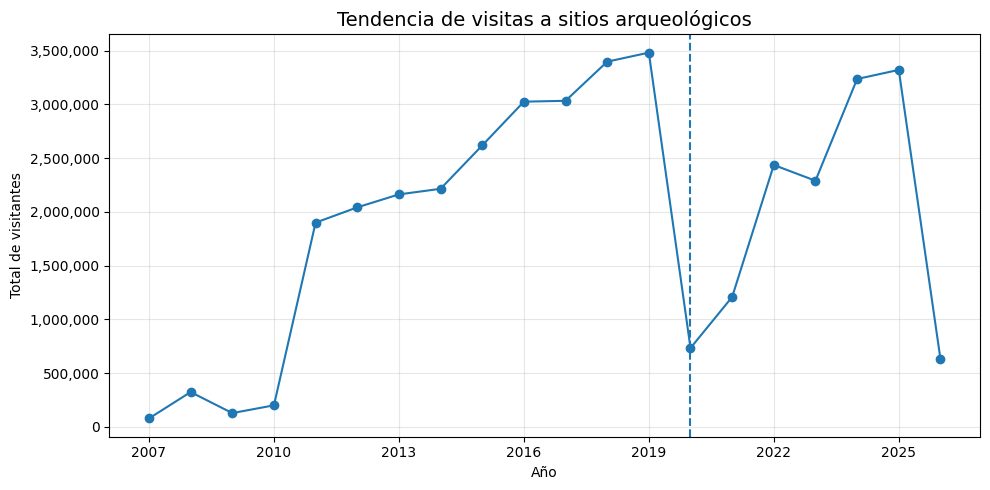

In [20]:
# 6. ANÁLISIS 1: VISITAS POR AÑO
# Asegurar que 'anio' sea entero
df['anio'] = df['anio'].astype(int)

# Agrupar por año(sumanos todos los visitantes por cada año)
visitas_anio = df.groupby('anio')['total_visitantes'].sum()

# Gráfico
plt.figure(figsize=(10,5))
visitas_anio.plot(marker='o') #ponemos puntos en cada año

# Línea vertical en pandemia
plt.axvline(x=2020, linestyle='--')

plt.title("Tendencia de visitas a sitios arqueológicos", fontsize=14)
plt.xlabel("Año")
plt.ylabel("Total de visitantes")
# para no mostrar con decimales
import matplotlib.ticker as ticker

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
# hasta aqui
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

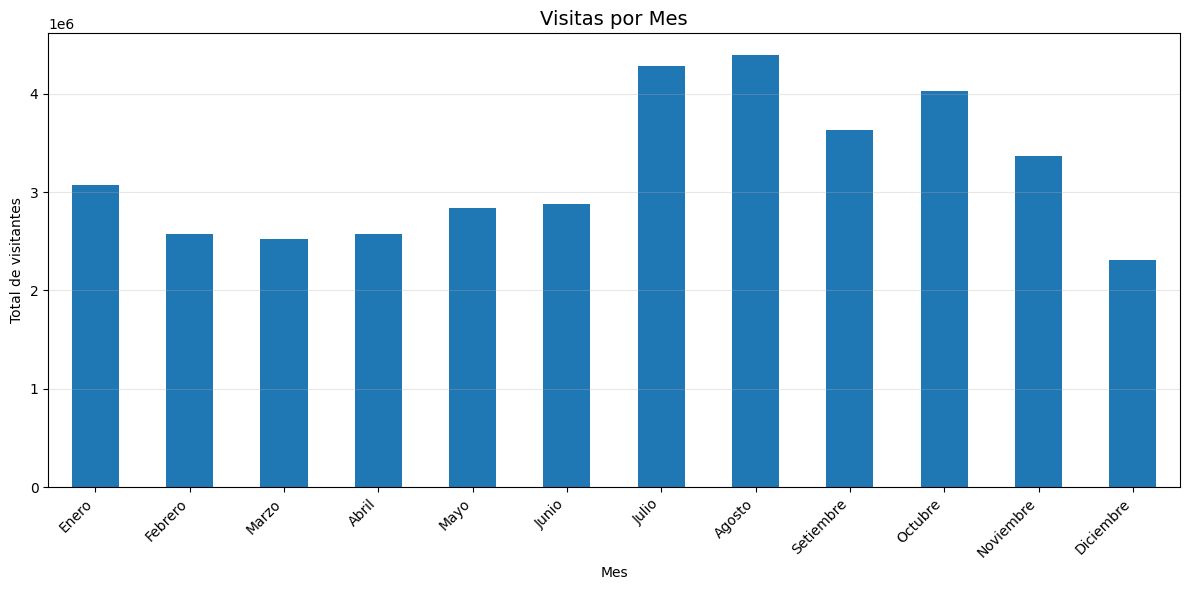

In [21]:
# 7. ANÁLISIS 2: VISITAS POR MES
visitas_mes = df.groupby('mes')['total_visitantes'].sum() #Sumamos los visitantes de cada mes sin importar el año
#deninimos el orden correcto de meses
orden_meses = [
    'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
    'Julio', 'Agosto', 'Setiembre', 'Octubre', 'Noviembre', 'Diciembre'
]

visitas_mes = visitas_mes.reindex(orden_meses) #reordenamos los meses

plt.figure(figsize=(12,6))
visitas_mes.plot(kind='bar')

plt.title("Visitas por Mes", fontsize=14)
plt.xlabel("Mes")
plt.ylabel("Total de visitantes")

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

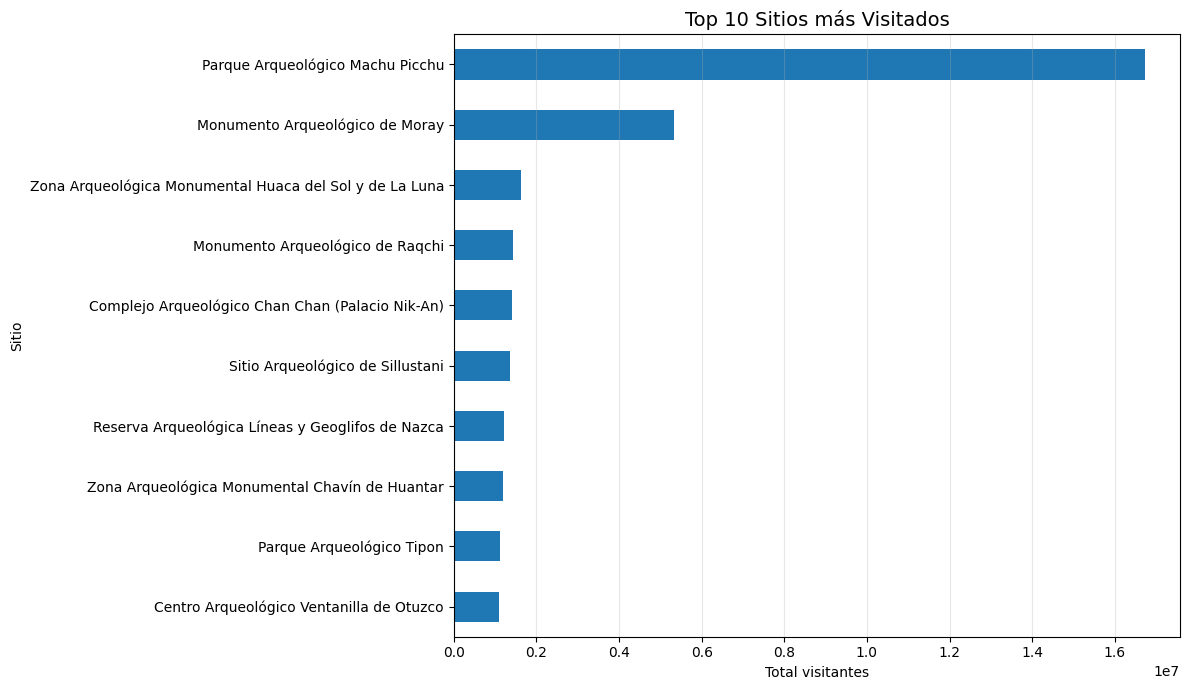

In [22]:
# 8. ANÁLISIS 3: TOP 10 SITIOS
plt.figure(figsize=(12,7))
top_sitios.sort_values().plot(kind='barh') #Ordenamos de mayor a menor y creamos barras horizontales

plt.title("Top 10 Sitios más Visitados", fontsize=14)
plt.xlabel("Total visitantes")
plt.ylabel("Sitio")

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

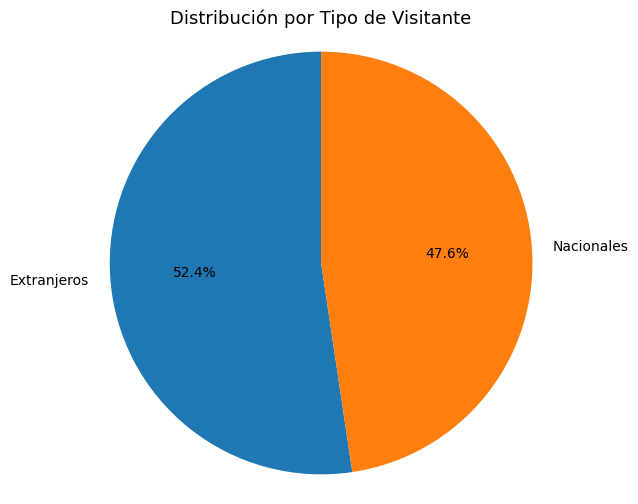

In [24]:
# 9. ANÁLISIS 4: TIPO DE VISITANTE
plt.figure(figsize=(6,6))
#haremos que el grágico se circular, mostraremos porcentajes y rotamos el grafico para mejor visualizacion
tipo.plot(kind='pie',
          autopct='%1.1f%%',
          startangle=90)

plt.title("Distribución por Tipo de Visitante", fontsize=13)
plt.ylabel("")
plt.axis('equal')  # Hace el círculo perfecto
plt.show()


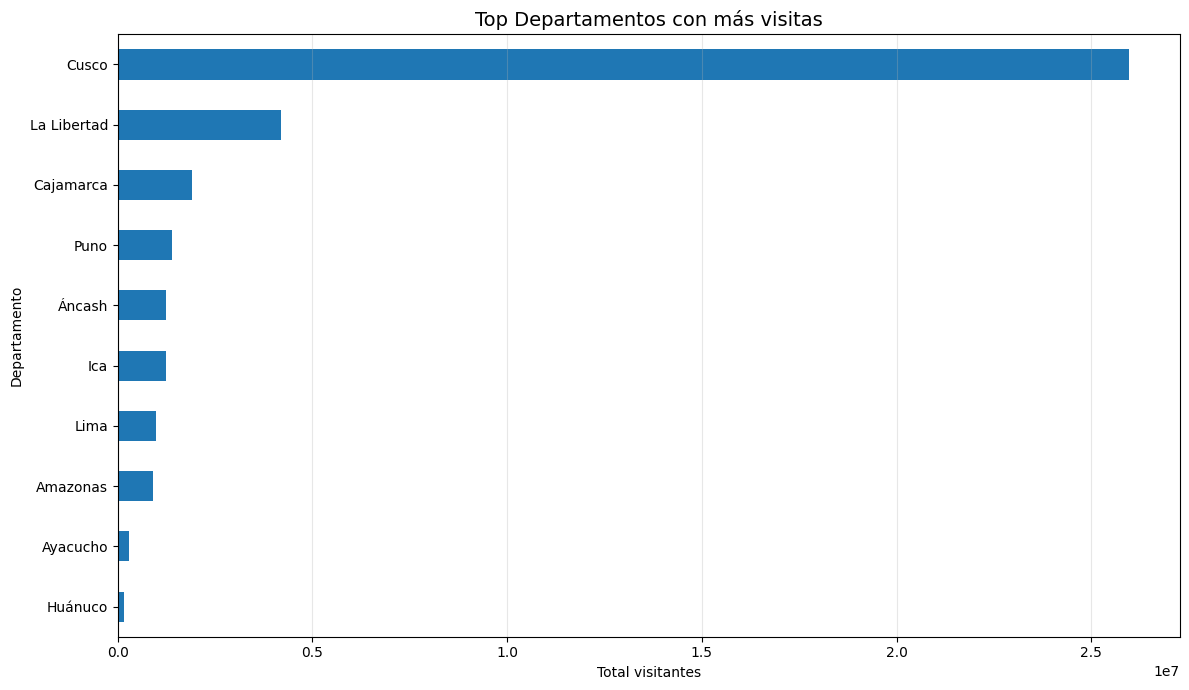

In [25]:
# 10. ANÁLISIS 5: POR DEPARTAMENTO
plt.figure(figsize=(12,7))
dpto.sort_values().plot(kind='barh') #Ordenamos de menor a mayor usando barras horizontales

plt.title("Top Departamentos con más visitas", fontsize=14)
plt.xlabel("Total visitantes")
plt.ylabel("Departamento")

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

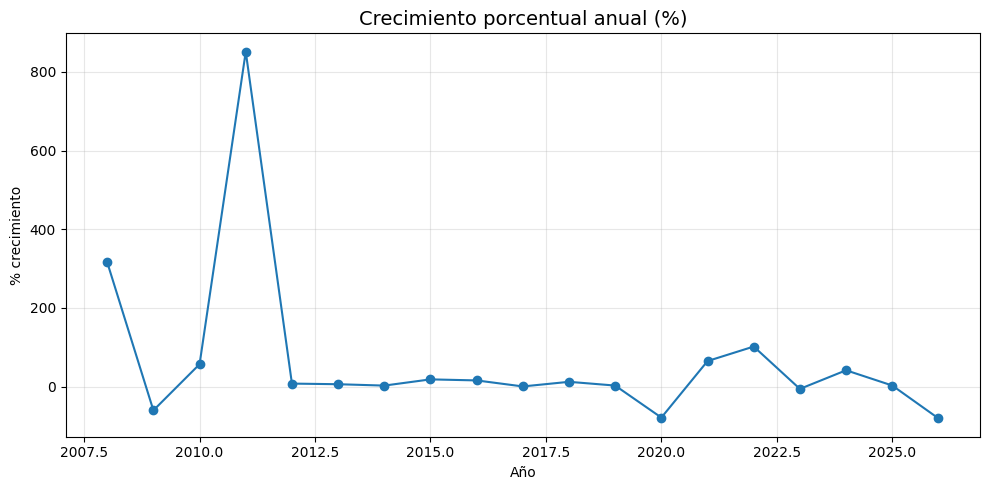

In [26]:
# 11. ANÁLISIS: CRECIMIENTO ANUAL

# Asegurar orden por año (IMPORTANTE)
visitas_anio = visitas_anio.sort_index()

# Calcular crecimiento %
crecimiento = visitas_anio.pct_change() * 100

plt.figure(figsize=(10,5))
crecimiento.plot(marker='o')

plt.title("Crecimiento porcentual anual (%)", fontsize=14)
plt.xlabel("Año")
plt.ylabel("% crecimiento")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

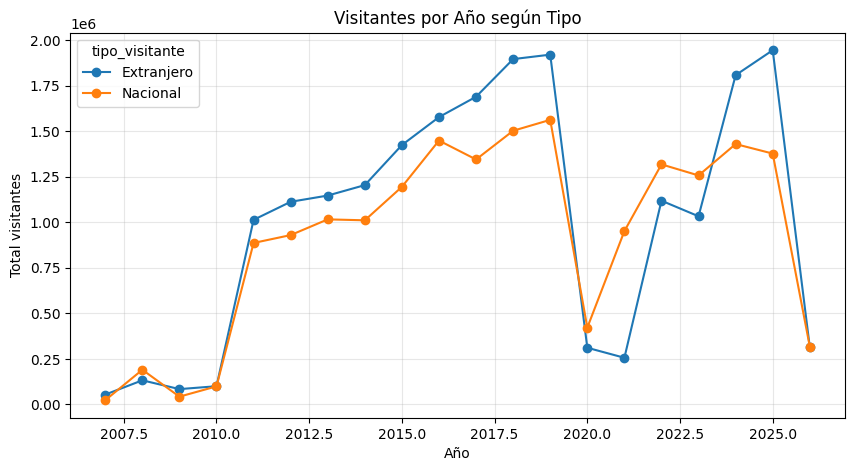

In [27]:
#Comparación de tipo de visitante en el tiempo
tipo_anio = df.groupby(['anio','tipo_visitante'])['total_visitantes'].sum().unstack()

tipo_anio.plot(figsize=(10,5), marker='o')

plt.title("Visitantes por Año según Tipo")
plt.xlabel("Año")
plt.ylabel("Total visitantes")
plt.grid(alpha=0.3)
plt.show()